In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from scipy import stats
warnings.filterwarnings('ignore')

In [2]:
BASE_PATH = r'C:\Users\Shivam Mohite\OneDrive\Desktop\Beacon\Data\ESA-Mission1\ESA-Mission1'
channels_path      = os.path.join(BASE_PATH, "channels.csv") #path for channels.csv
labels_path        = os.path.join(BASE_PATH, "labels.csv") #path for labels.csv
anomaly_types_path = os.path.join(BASE_PATH, "anomaly_types.csv") #path for anomaly_types.csv
telecommands_path  = os.path.join(BASE_PATH, "telecommands.csv") #path for telecommands.csv
channels_folder      = os.path.join(BASE_PATH, "channels") #path for channels folder
telecommands_folder  = os.path.join(BASE_PATH, "telecommands") #path for telecommands folder

The satellite has 76 sensors monitoring health, Each sensor is called a channel
- channels.csv lists all 76 sensors and marks whether each is a target sensor.
    - Target = YES means the sensor is one of the 58 important ones engineers watch closely.
    - The other 18 sensors provide background context.
- labels.csv tells you exactly when something went wrong over the 14-year mission and which sensor(s) were involved.
    - In short, it is the list of all known incidents during the mission.

- anomaly_types.csv contains the diagnosis for every recorded incident.
    - It tells you what kind of problem each incident was.
    - Important finding: 82% of incidents affected multiple sensors at the same time, not just one.

- telecommands.csv logs every command sent from ground control to the satellite.
    - Examples: turn on camera, adjust solar panels, go into safe mode.
    - Since anomalies sometimes happen right after a command, this file helps explain why anomalies occur.
    
Flow:
- channels.csv: all 76 sensors and what they monitor
- channel readings every 3 minutes for 14 years
- labels.csv: timestamps when things went wrong
- anomaly_types.csv: type of problem for each incident
- telecommands.csv: commands sent that may have caused it

In [3]:
df_channels      = pd.read_csv(channels_path)
df_labels        = pd.read_csv(labels_path, parse_dates=['StartTime', 'EndTime'])
df_anomaly_types = pd.read_csv(anomaly_types_path)
df_telecommands  = pd.read_csv(telecommands_path)
print(f"  channels.csv      → {df_channels.shape[0]} rows, {df_channels.shape[1]} columns")
print(f"  labels.csv        → {df_labels.shape[0]} rows, {df_labels.shape[1]} columns")
print(f"  anomaly_types.csv → {df_anomaly_types.shape[0]} rows, {df_anomaly_types.shape[1]} columns")
print(f"  telecommands.csv  → {df_telecommands.shape[0]} rows, {df_telecommands.shape[1]} columns")

  channels.csv      → 76 rows, 5 columns
  labels.csv        → 3589 rows, 4 columns
  anomaly_types.csv → 200 rows, 7 columns
  telecommands.csv  → 698 rows, 2 columns


# ESA-Mission1 — Exploratory Data Analysis Insights

-------------------------------------------------------------------------------------------------------------------------------------------

### channels.csv — Sensor Registry
- **76 total channels**, organized into **4 subsystems**.
  - `subsystem_6` is the largest (42 channels), followed by `subsystem_1` (17), `subsystem_3` (11), `subsystem_5` (6).
  - This implies subsystem_6 is the most heavily instrumented and likely the most complex/critical subsystem on the satellite.
- **6 physical units** are measured across channels, with `physical_unit_3` dominating (42 channels) — suggesting one dominant sensor type (e.g. temperature or voltage) is monitored far more than others.
- Channels are further organized into **18 groups**, with Groups 2 and 3 being the busiest (8 channels each).
- **Target split: 58 channels = YES, 18 channels = NO.**
  - Only the 58 `Target=YES` channels are used for anomaly detection.
  - The 18 `NO` channels are contextual/supporting signals only.

**Implication for modeling:** The anomaly detection model should focus on the 58 target channels as primary inputs, but the 18 non-target channels may still be useful as auxiliary/contextual features (e.g., explaining *why* a target channel deviated).

---

In [4]:
df_channels

,Channel,Subsystem,Physical Unit,Group,Target
0,channel_1,subsystem_1,physical_unit_1,1,NO
1,channel_2,subsystem_1,physical_unit_1,1,NO
2,channel_3,subsystem_1,physical_unit_1,1,NO
3,channel_4,subsystem_1,physical_unit_2,2,NO
4,channel_5,subsystem_1,physical_unit_2,2,NO
...,...,...,...,...,...
71,channel_72,subsystem_3,physical_unit_4,18,YES
72,channel_73,subsystem_3,physical_unit_4,18,YES
73,channel_74,subsystem_3,physical_unit_4,18,YES
74,channel_75,subsystem_3,physical_unit_4,18,YES


In [5]:
df_channels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Channel        76 non-null     object
 1   Subsystem      76 non-null     object
 2   Physical Unit  76 non-null     object
 3   Group          76 non-null     int64 
 4   Target         76 non-null     object
dtypes: int64(1), object(4)
memory usage: 3.1+ KB


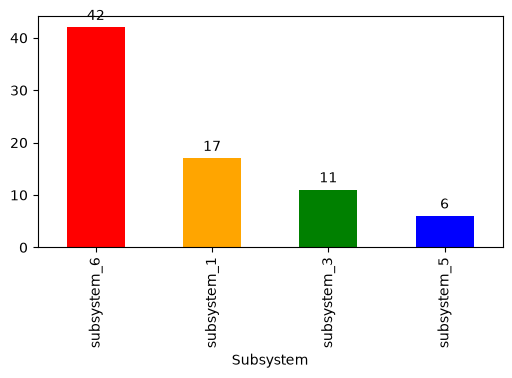

In [6]:
counts = df_channels['Subsystem'].value_counts()
ax = counts.plot(kind='bar',figsize=(6, 3),color=['Red', 'Orange', 'Green', 'Blue'])
ax.bar_label(ax.containers[0], padding=3)
plt.show()

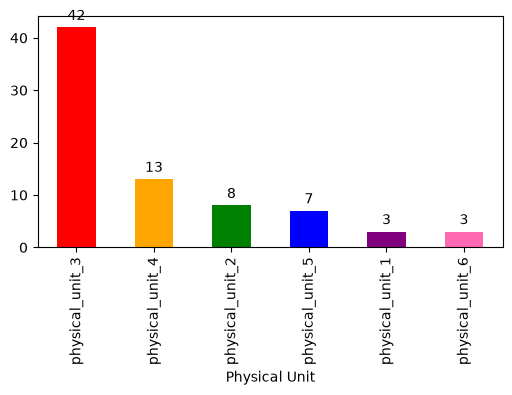

In [7]:
counts = df_channels['Physical Unit'].value_counts()
ax = counts.plot(kind='bar', figsize=(6,3), color=['Red', 'Orange', 'Green', 'Blue', 'purple','hotpink'])
ax.bar_label(ax.containers[0], padding=3)
plt.show()

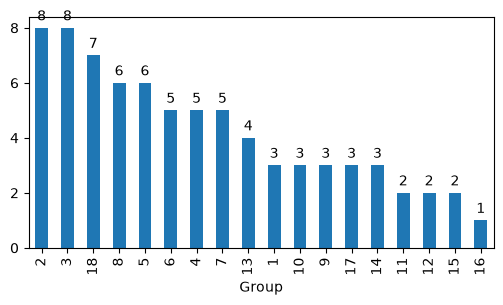

In [8]:
counts = df_channels['Group'].value_counts()
ax = counts.plot(kind='bar', figsize=(6,3))
ax.bar_label(ax.containers[0], padding=3)
plt.show()

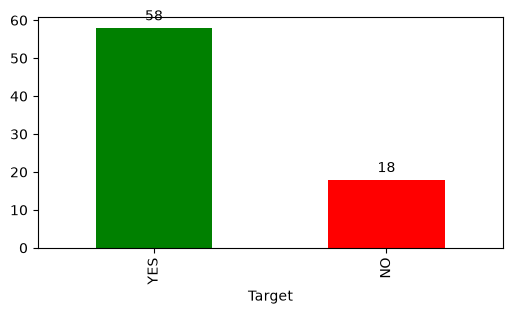

In [9]:
counts = df_channels['Target'].value_counts()
ax = counts.plot(kind='bar', figsize=(6,3), color=['Green', 'Red'])
ax.bar_label(ax.containers[0], padding=3)
plt.show()

-------------------------------------------------------------------------------------------------------------------------------------------

### anomaly_types.csv — Anomaly Taxonomy
- **200 unique anomaly events**, each tagged across 5 dimensions:
  - **Category:** Anomaly (118), Rare Event (78), Communication Gap (4)
  - **Dimensionality:** Multivariate (164, ~82%) vs Univariate (32, ~18%)
  - **Locality:** Global (113) vs Local (83)
  - **Length:** Subsequence (184, ~92%) vs Point (12, ~8%)
  - **Class:** 22 fine-grained fault classes (anonymized), heavily imbalanced — `class_7` (45 events) and `class_22` (33 events) dominate, while many classes have only 1–3 events.

**Implication for modeling:**
- The **82% multivariate dominance** reinforces that the model must learn cross-channel relationships, not just per-channel thresholds.
- The **92% subsequence dominance** (matches the Duration analysis above) confirms the model should be optimized for detecting sustained pattern deviations, not just single-point spikes.
- The heavy class imbalance (some classes with only 1–3 examples) means **supervised multi-class fault classification is not viable** with this little data per class — reinforcing the case for **unsupervised/semi-supervised anomaly detection** (e.g., LSTM Autoencoder trained on normal data) rather than trying to classify fault types directly.

---

In [10]:
df_anomaly_types

,ID,Class,Subclass,Category,Dimensionality,Locality,Length
0,id_1,class_6,subclass_1,Rare Event,Multivariate,Global,Subsequence
1,id_2,class_7,subclass_1,Anomaly,Multivariate,Local,Subsequence
2,id_3,class_7,subclass_1,Anomaly,Multivariate,Global,Subsequence
3,id_4,class_7,subclass_1,Anomaly,Multivariate,Local,Subsequence
4,id_5,class_7,subclass_1,Anomaly,Multivariate,Local,Subsequence
...,...,...,...,...,...,...,...
195,id_196,class_22,subclass_2,Rare Event,Univariate,Global,Subsequence
196,id_197,class_22,subclass_2,Rare Event,Univariate,Global,Subsequence
197,id_198,class_22,subclass_2,Rare Event,Univariate,Global,Subsequence
198,id_199,class_22,subclass_1,Anomaly,Univariate,Local,Subsequence


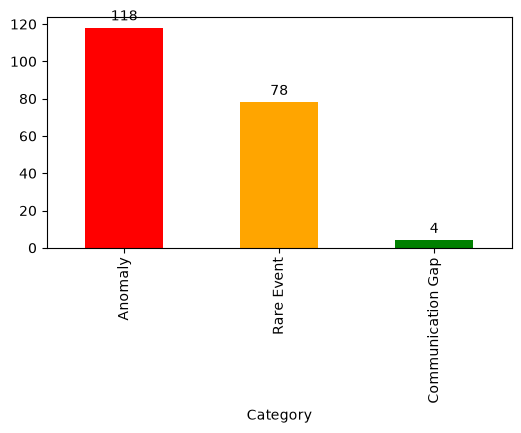

In [11]:
counts = df_anomaly_types['Category'].value_counts()
ax = counts.plot(kind='bar', figsize=(6,3), color=['Red', 'Orange', 'Green'])
ax.bar_label(ax.containers[0], padding=3)
plt.show()

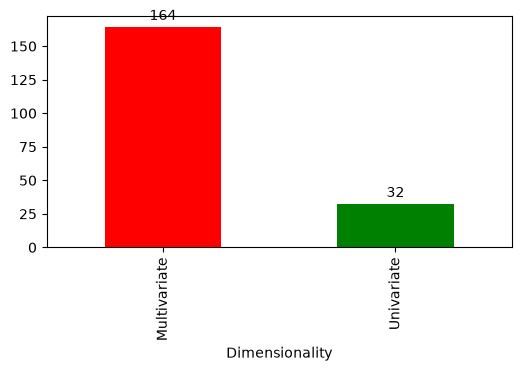

In [12]:
counts = df_anomaly_types['Dimensionality'].value_counts()
ax = counts.plot(kind='bar', figsize=(6,3), color=['Red','Green'])
ax.bar_label(ax.containers[0], padding=3)
plt.show()

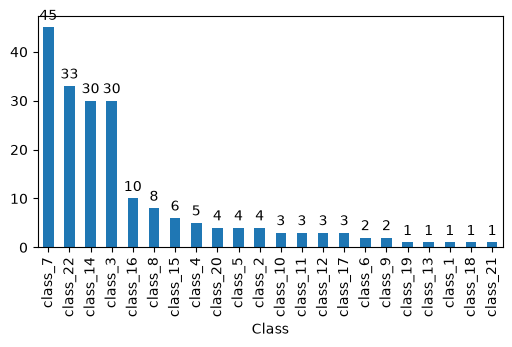

In [13]:
counts = df_anomaly_types['Class'].value_counts()
ax = counts.plot(kind='bar', figsize=(6,3))
ax.bar_label(ax.containers[0], padding=3)
plt.show()

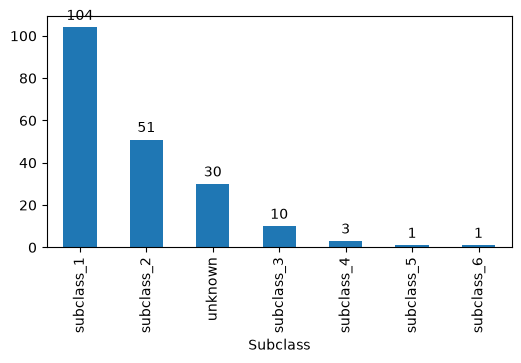

In [14]:
counts = df_anomaly_types['Subclass'].value_counts()
ax = counts.plot(kind='bar', figsize=(6,3))
ax.bar_label(ax.containers[0], padding=3)
plt.show()

### labels.csv — Anomaly Ground Truth
- **200 unique anomaly events** spanning **3,589 channel-level label rows** — confirming that most anomalies affect *multiple channels simultaneously* (multivariate by nature).
- **58 unique channels** ever appear in labels — exactly matching the `Target=YES` channels from `channels.csv`. This is a strong consistency check: only target channels are ever labeled.
- **Date range:** Feb 2000 → Dec 2013 (~14 years of labeled history).
- **Channel clustering confirmed:** `channel_41`–`channel_46` show nearly identical anomaly counts (212, 211, 211, 210, 208, 203) and were confirmed to belong to the **same Group** in `channels.csv`. This is strong evidence of **correlated, multivariate fault events** — when one channel in this group goes anomalous, its neighbors almost always do too.
- A second, smaller cluster (`channel_21`, `channel_14`, `channel_29`, ~95 each) suggests a separate recurring fault pattern in a different part of the satellite.


In [15]:
df_labels

,ID,Channel,StartTime,EndTime
0,id_1,channel_12,2004-12-01 20:42:15.429000+00:00,2004-12-08 22:55:45.429000+00:00
1,id_1,channel_13,2004-12-01 20:42:15.429000+00:00,2004-12-08 22:55:45.429000+00:00
2,id_1,channel_14,2004-12-01 20:43:45.429000+00:00,2004-12-02 02:57:15.429000+00:00
3,id_1,channel_15,2004-12-01 20:45:00.429000+00:00,2004-12-02 02:58:45.429000+00:00
4,id_1,channel_16,2004-12-01 20:43:45.429000+00:00,2004-12-16 16:52:30.429000+00:00
...,...,...,...,...
3584,id_200,channel_52,2000-10-10 00:50:40.701000+00:00,2000-10-11 04:56:40.701000+00:00
3585,id_200,channel_57,2000-10-10 00:50:05.817000+00:00,2000-10-12 12:00:05.817000+00:00
3586,id_200,channel_58,2000-10-10 01:03:35.817000+00:00,2000-10-13 00:02:05.817000+00:00
3587,id_200,channel_59,2000-10-10 00:46:35.817000+00:00,2000-10-12 09:16:05.817000+00:00


In [16]:
print(f"\nTotal anomaly events: {df_labels['ID'].nunique()}")
print(f"Total channels affected: {df_labels['Channel'].nunique()}")
print(f"\nDate range of anomalies:")
print(f"  Earliest: {df_labels['StartTime'].min()}")
print(f"  Latest:   {df_labels['EndTime'].max()}")
# How long do anomalies last?
df_labels['Duration'] = df_labels['EndTime'] - df_labels['StartTime']
print(f"\nAnomaly Duration Stats:")
print(f"  Shortest: {df_labels['Duration'].min()}")
print(f"  Longest:  {df_labels['Duration'].max()}")
print(f"  Average:  {df_labels['Duration'].mean()}")
print(f"  Median:   {df_labels['Duration'].median()}")


Total anomaly events: 200
Total channels affected: 58

Date range of anomalies:
  Earliest: 2000-02-10 01:31:16.347000+00:00
  Latest:   2013-12-06 06:44:59.943000+00:00

Anomaly Duration Stats:
  Shortest: 0 days 00:00:00
  Longest:  40 days 06:59:11.994000
  Average:  1 days 22:40:21.247070771
  Median:   0 days 03:15:00



Top 10 most affected channels:


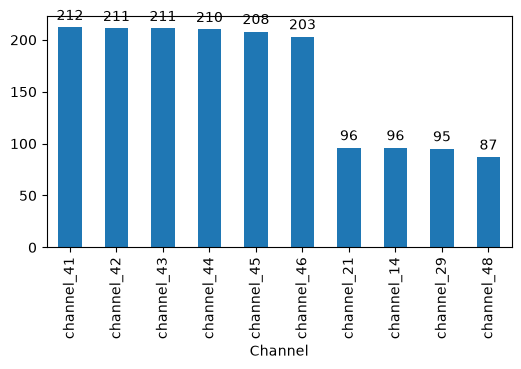

In [17]:
print(f"\nTop 10 most affected channels:")
counts = df_labels['Channel'].value_counts().head(10)
ax = counts.plot(kind='bar', figsize=(6,3))
ax.bar_label(ax.containers[0], padding=3)
plt.show()

In [18]:
duration_seconds = df_labels['Duration'].dt.total_seconds()
skewness = duration_seconds.skew()
print(f"Skewness of Duration: {skewness:.3f}")

Skewness of Duration: 4.478


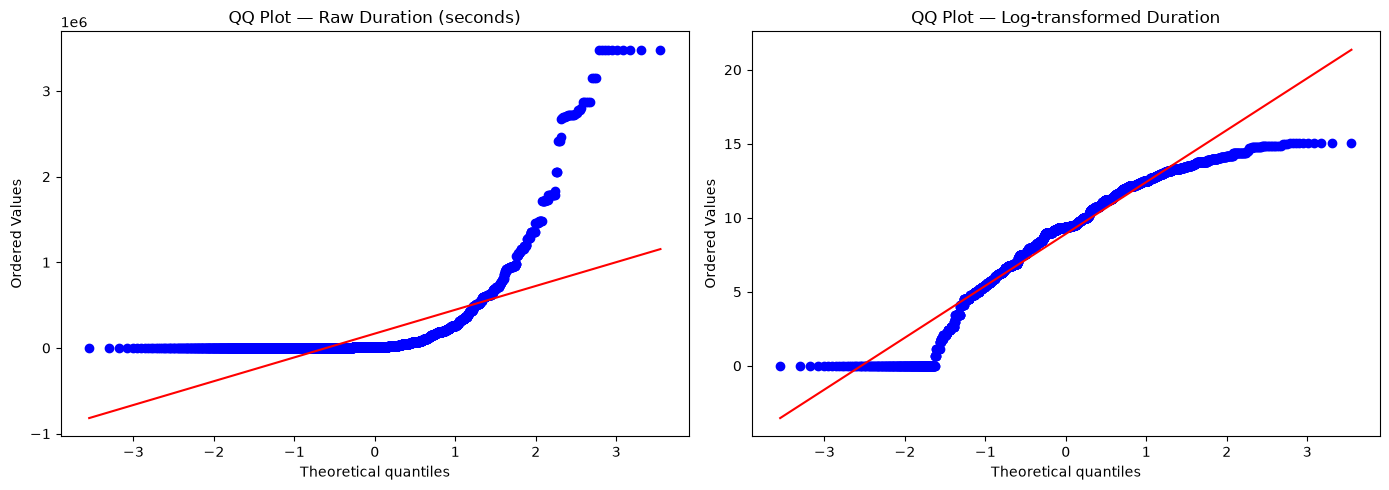

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stats.probplot(duration_seconds, dist="norm", plot=axes[0])
axes[0].set_title("QQ Plot — Raw Duration (seconds)")
log_duration = np.log1p(duration_seconds)
stats.probplot(log_duration, dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot — Log-transformed Duration")

plt.tight_layout()
plt.show()

### telecommands.csv — Ground Control Commands

- **698 unique telecommands**, each assigned a **Priority level (0–3)**.
- Priority distribution is heavily skewed toward routine commands:
  - Priority 0: 345 (most common — routine/housekeeping)
  - Priority 1: 323
  - Priority 2: 19
  - Priority 3: 11 (rarest — likely urgent/critical interventions)

**Implication for modeling:** Telecommands are a potential **confounding factor** for anomaly detection — a telemetry shift caused by an intentional ground command (e.g., entering safe mode) should *not* be flagged as a fault. Cross-referencing telecommand timestamps against detected anomalies will help distinguish **true anomalies** from **expected operational changes**, reducing false positives.

---

In [20]:
df_telecommands

,Telecommand,Priority
0,telecommand_1,1
1,telecommand_2,1
2,telecommand_3,1
3,telecommand_4,1
4,telecommand_5,1
...,...,...
693,telecommand_694,0
694,telecommand_695,0
695,telecommand_696,0
696,telecommand_697,0


In [21]:
df_telecommands['Priority'].value_counts()

Priority
0    345
1    323
2     19
3     11
Name: count, dtype: int64

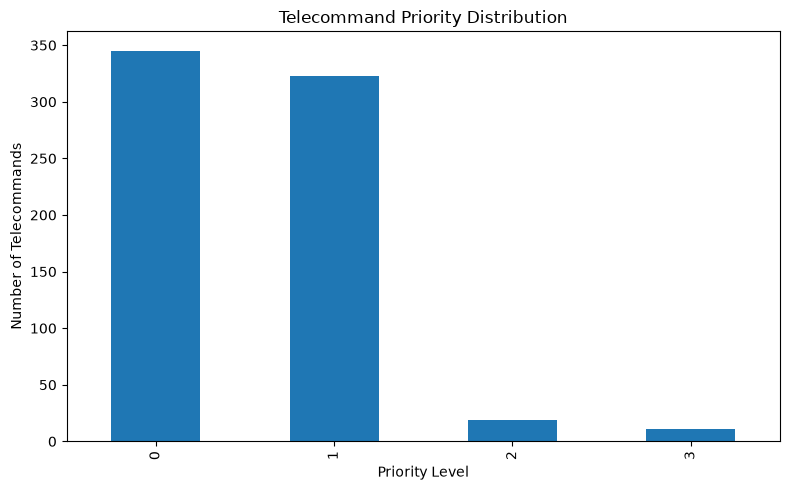

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
df_telecommands['Priority'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xlabel("Priority Level")
ax.set_ylabel("Number of Telecommands")
ax.set_title("Telecommand Priority Distribution")
plt.tight_layout()
plt.show()


In [23]:
channel_41 = "channel_41/channel_41"
channel_16 = "channel_16/channel_16"
channel_22 = "channel_22/channel_22"
channel_file_path = os.path.join(channels_folder, channel_41)
channel_file_path1 = os.path.join(channels_folder, channel_16)
channel_file_path2 = os.path.join(channels_folder, channel_22)
df_ch41 = pd.read_pickle(channel_file_path)
df_ch16 = pd.read_pickle(channel_file_path1)
df_ch22 = pd.read_pickle(channel_file_path2)

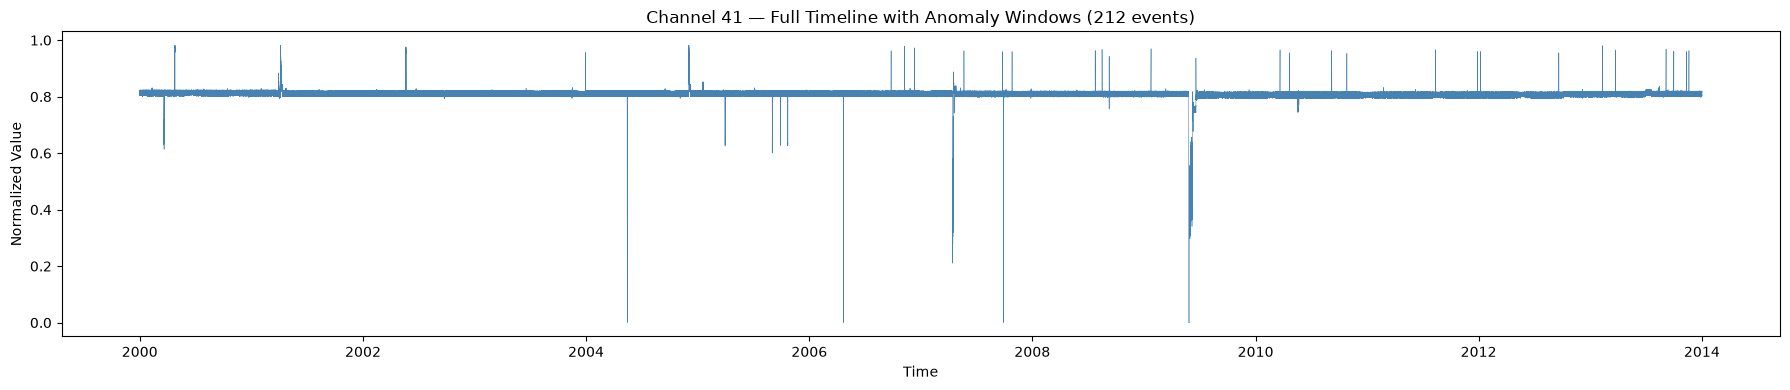

In [24]:
# Cell 8 — Channel 41 Anomaly Window Visualization
ch41_anomalies = df_labels[df_labels['Channel'] == 'channel_41']
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(df_ch41.index, df_ch41['channel_41'],linewidth=0.4, color='steelblue')
ax.set_title(f"Channel 41 — Full Timeline with Anomaly Windows ({len(ch41_anomalies)} events)")
ax.set_xlabel("Time")
ax.set_ylabel("Normalized Value")
plt.tight_layout()
plt.show()

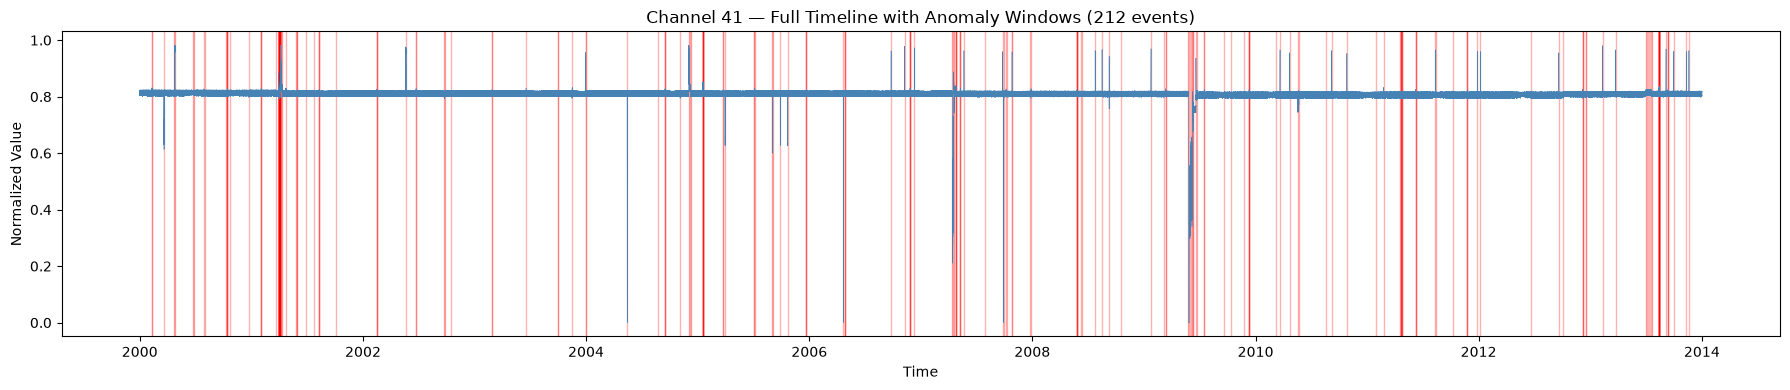

In [25]:
# Cell 8 — Channel 41 Anomaly Window Visualization
ch41_anomalies = df_labels[df_labels['Channel'] == 'channel_41']
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(df_ch41.index, df_ch41['channel_41'],linewidth=0.4, color='steelblue')
for _, row in ch41_anomalies.iterrows():
    ax.axvspan(row['StartTime'], row['EndTime'],color='red', alpha=0.3)
ax.set_title(f"Channel 41 — Full Timeline with Anomaly Windows ({len(ch41_anomalies)} events)")
ax.set_xlabel("Time")
ax.set_ylabel("Normalized Value")
plt.tight_layout()
plt.show()

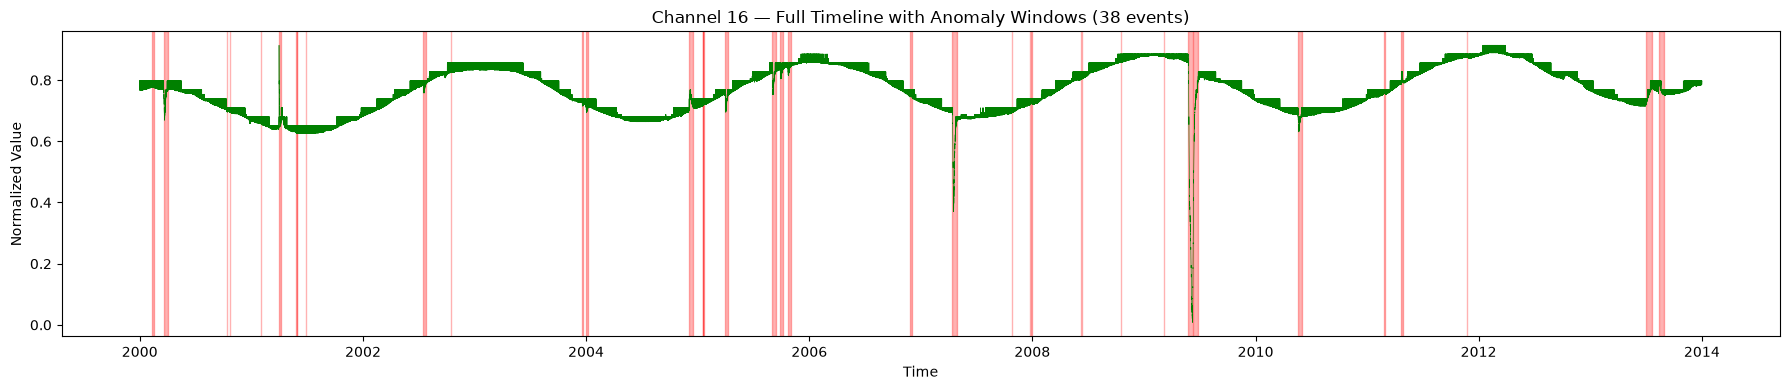

Channel 16 total anomaly windows: 38


In [26]:
# Cell 9 — Channel 16 Anomaly Window Visualization
ch16_anomalies = df_labels[df_labels['Channel'] == 'channel_16']
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(df_ch16.index, df_ch16['channel_16'],linewidth=0.4, color='green')
for _, row in ch16_anomalies.iterrows():
    ax.axvspan(row['StartTime'], row['EndTime'],color='red', alpha=0.3)
ax.set_title(f"Channel 16 — Full Timeline with Anomaly Windows ({len(ch16_anomalies)} events)")
ax.set_xlabel("Time")
ax.set_ylabel("Normalized Value")
plt.tight_layout()
plt.show()
print(f"Channel 16 total anomaly windows: {len(ch16_anomalies)}")

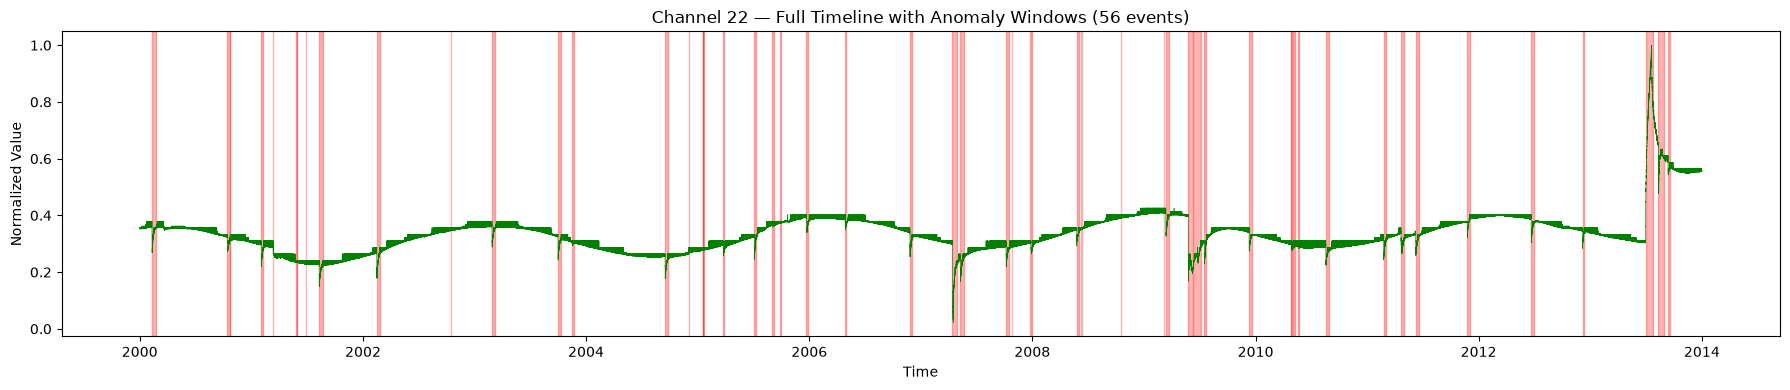

Channel 22 total anomaly windows: 56


In [27]:
# Cell  — Channel 22 Anomaly Window Visualization
ch22_anomalies = df_labels[df_labels['Channel'] == 'channel_22']
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(df_ch22.index, df_ch22['channel_22'],linewidth=0.4, color='green')
for _, row in ch22_anomalies.iterrows():
    ax.axvspan(row['StartTime'], row['EndTime'],color='red', alpha=0.3)
ax.set_title(f"Channel 22 — Full Timeline with Anomaly Windows ({len(ch22_anomalies)} events)")
ax.set_xlabel("Time")
ax.set_ylabel("Normalized Value")
plt.tight_layout()
plt.show()
print(f"Channel 22 total anomaly windows: {len(ch22_anomalies)}")

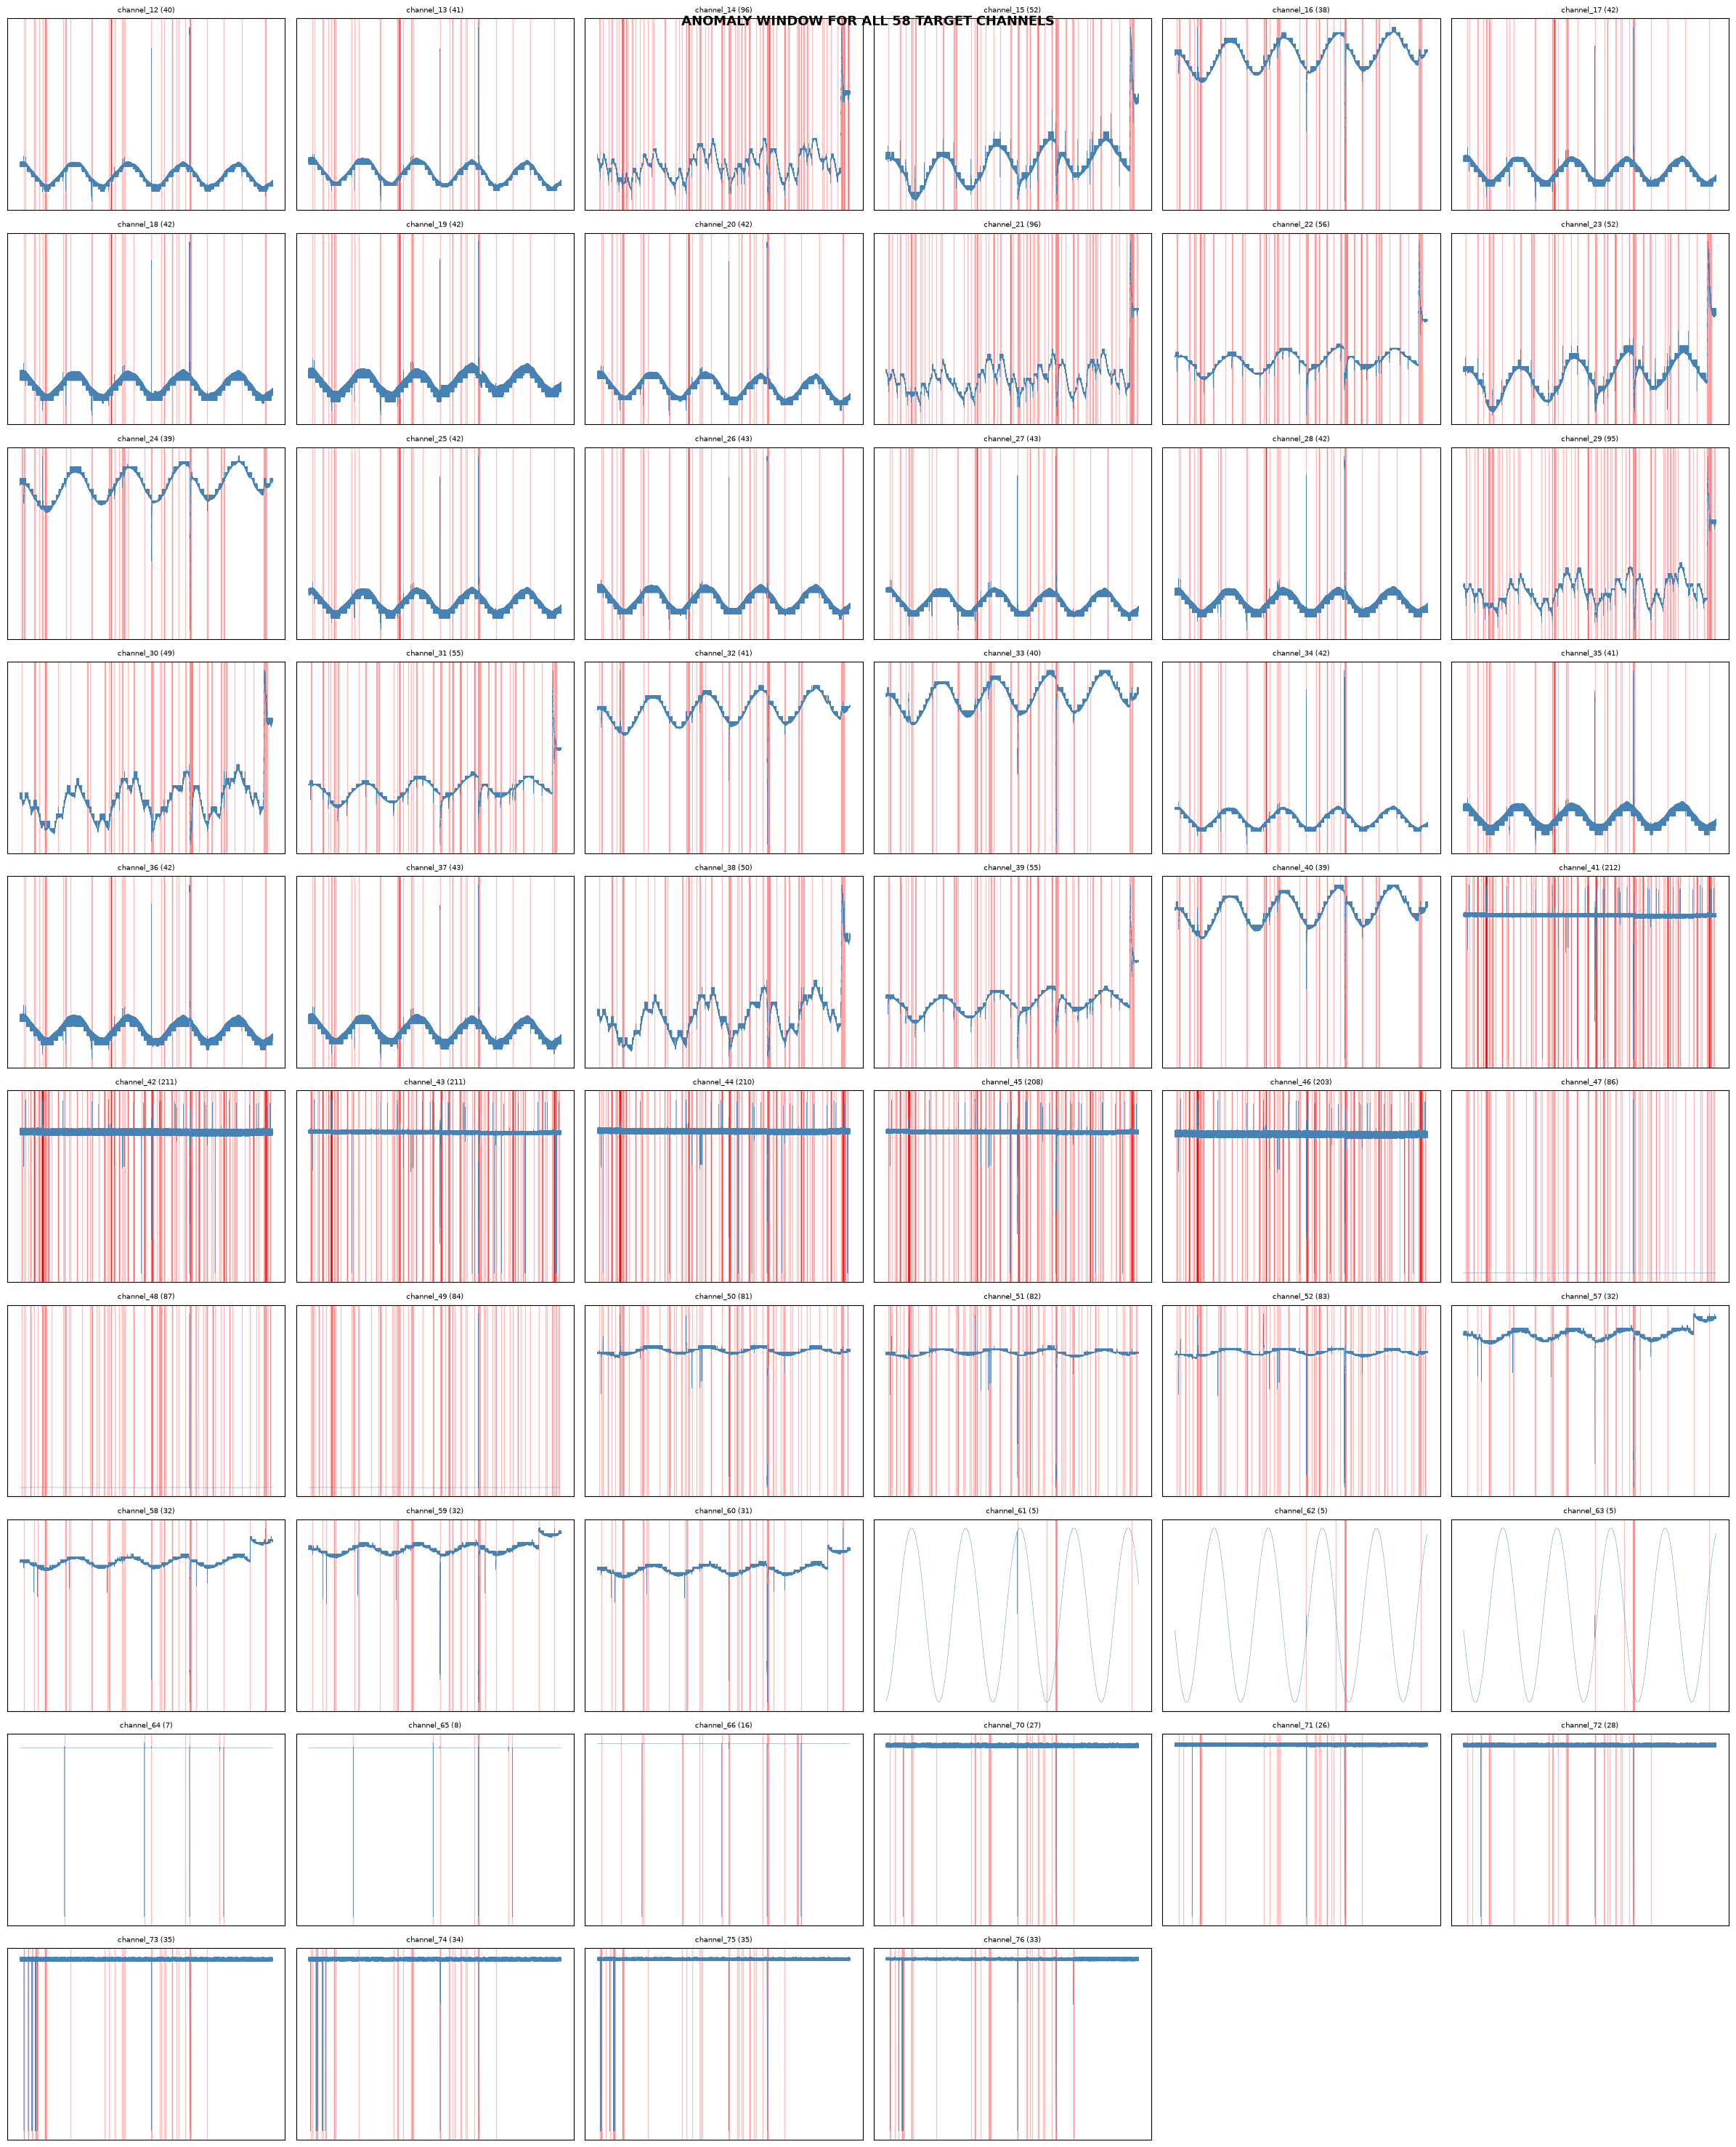

In [28]:
# ANOMALY WINDOW THUMBNAILS FOR ALL 76 CHANNELS
import math
target_channels = df_channels[df_channels['Target'] == 'YES']['Channel'].tolist() # Get all target channels (YES only — 58 channels)
# Grid layout
n_cols = 6
n_rows = math.ceil(len(target_channels) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, n_rows * 3))
axes = axes.flatten()
for i, ch_name in enumerate(sorted(target_channels)):
    ax = axes[i]
    try:
        # Load channel
        ch_path = os.path.join(channels_folder, f"{ch_name}/{ch_name}")
        df_ch = pd.read_pickle(ch_path)
        # Plot signal
        ax.plot(df_ch.index, df_ch[ch_name],
                linewidth=0.3, color='steelblue')
        # Overlay anomaly windows
        ch_anomalies = df_labels[df_labels['Channel'] == ch_name]
        for _, row in ch_anomalies.iterrows():
            ax.axvspan(row['StartTime'], row['EndTime'],
                       color='red', alpha=0.25)
        ax.set_title(f"{ch_name} ({len(ch_anomalies)})", fontsize=7)
        ax.set_xticks([])
        ax.set_yticks([])
    except Exception as e:
        ax.set_title(f"{ch_name} — ERROR", fontsize=7)
        ax.axis('off')
# Hide unused subplots
for j in range(len(target_channels), len(axes)):
    axes[j].axis('off')
plt.suptitle("ANOMALY WINDOW FOR ALL 58 TARGET CHANNELS",fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('../Output/all_channels_overview.png', dpi=150, bbox_inches='tight') #Uncomment this line to save the figure as a PNG file
plt.show()

## 📊 Full Channel Grid — EDA Insights

### What the 58-Channel Overview Reveals

Running the full thumbnail grid across all 58 target channels exposed **four distinct signal personality types** — a significantly richer picture than the 3 channels we examined individually.

---

### 🔵 Personality Type 1 — Slow Sinusoidal Wave (Dominant)
**Channels:** 12, 13, 14, 15, 16, 17, 18, 19, 20, 24, 25, 26, 27, 28, 29 and many more

The most common signal type — accounting for roughly **60%+ of all 58 channels**.  
These channels follow a slow, rhythmic wave pattern cycling over multi-year periods.  
Almost certainly driven by **seasonal/orbital effects** — solar exposure angle or thermal cycling changing over time.

> **Modeling implication:** A fixed threshold is completely useless here — the signal oscillates naturally between wide value ranges. The LSTM must *learn the wave pattern* before it can judge what counts as anomalous.

---

### 🔴 Personality Type 2 — The Flatline Clusters (Two Groups Found)
**Group A:** Channels 41, 42, 43, 44, 45, 46 ← already identified  
**Group B:** Channels 70, 71, 72, 73, 74, 75, 76 ← **newly discovered in this grid**

Dead-flat blue lines completely buried under dense red anomaly bands.  
Both groups show near-identical behavior — stable baseline with violent, sudden deviations.

> **New Finding:** The bottom rows (ch 70–76) form a **second flatline cluster** with the same heavy red banding as ch 41–46. This strongly suggests a second correlated fault group in a different subsystem. The correlation matrix will confirm whether these two clusters are independent or linked.

---

### 🟡 Personality Type 3 — Irregular / Noisy Drifters
**Channels:** 29, 30, 31, 38, 39, 48, 49, 50, 51, 52, 53, 57, 58, 59, 60

Neither clean waves nor flat lines — these channels show **irregular, noisy patterns** with higher natural variability. More difficult to model because the baseline itself is unpredictable.

> **Modeling implication:** These channels will likely produce higher baseline reconstruction error even during normal operation — meaning the anomaly threshold must be tuned *per channel* rather than using one global threshold.

---

### ⚪ Personality Type 4 — Sparse / Nearly Empty Signals
**Channels:** 61, 62, 63, 64, 65

Very sparse readings — barely any data points visible across the 14-year timeline.  
These are **infrequently sampled sensors**, possibly only active during specific mission phases.

> **Modeling implication:** These channels cannot be resampled to a 3-minute grid without massive gap-filling. Options: (1) exclude from the multivariate model, (2) treat separately with a different window strategy, or (3) use forward-fill imputation with a staleness flag.

---

### 🆕 Key New Finding — Second Flatline Cluster (ch 70–76)

| Cluster | Channels | Behavior | Status |
|---|---|---|---|
| Primary | 41, 42, 43, 44, 45, 46 | Flatline ~0.81, dense anomalies | Confirmed earlier |
| **Secondary** | **70, 71, 72, 73, 74, 75, 76** | **Flatline, dense anomalies** | **Newly discovered** |

Both clusters are visually identical in the grid. Whether they belong to the same subsystem, the same fault group, or are independently correlated will be answered by the **inter-channel correlation matrix** in the next cell.

---

### Summary Table — Signal Personality Distribution

| Type | Description | Approx. Count | Detection Difficulty |
|---|---|---|---|
| Sinusoidal wave | Slow multi-year cycling | ~35 channels | Medium |
| Flatline (Group A) | Flat at ~0.81, violent spikes | 6 channels (41–46) | Easy |
| Flatline (Group B) | Flat, dense red bands | 7 channels (70–76) | Easy |
| Noisy drifter | Irregular, high variability | ~7 channels | Hard |
| Sparse signal | Infrequent sampling | ~5 channels | Special handling needed |

---

> **Bottom line:** The LSTM Autoencoder must be robust enough to handle all four personality types simultaneously within a single multivariate model. The per-channel reconstruction error approach (flagging channels individually rather than one global score) will be essential given how differently these channels behave under normal conditions.

In [31]:
# Load all 58 target channels into one combined DataFrame
target_channels = df_channels[df_channels['Target'] == 'YES']['Channel'].tolist()
target_channels = sorted(target_channels)

channel_dfs = {}
failed = []

for i, ch_name in enumerate(target_channels):
    try:
        ch_path = os.path.join(channels_folder, f"{ch_name}/{ch_name}")
        df_temp = pd.read_pickle(ch_path)
        channel_dfs[ch_name] = df_temp[ch_name]
        if (i+1) % 10 == 0:
            print(f"  Loaded {i+1}/{len(target_channels)} channels...")
    except Exception as e:
        failed.append(ch_name)
        print(f"  ❌ Failed: {ch_name} — {e}")
print(f"Successfully loaded: {len(channel_dfs)} channels")

  Loaded 10/58 channels...
  Loaded 20/58 channels...
  Loaded 30/58 channels...
  Loaded 40/58 channels...
  Loaded 50/58 channels...
Successfully loaded: 58 channels


In [32]:
# Inter-Channel Correlation Analysis

# Resample each channel to 1-hour median to align timestamps
resampled = {}
for ch_name, series in channel_dfs.items():
    resampled[ch_name] = series.resample('1h').median()

df_combined = pd.DataFrame(resampled)

print(f"Combined DataFrame shape: {df_combined.shape}")
print(f"Time range: {df_combined.index.min()} → {df_combined.index.max()}")

Combined DataFrame shape: (122736, 58)
Time range: 2000-01-01 00:00:00 → 2013-12-31 23:00:00


In [33]:
df_combined 

,channel_12,channel_13,channel_14,channel_15,channel_16,channel_17,channel_18,channel_19,channel_20,channel_21,...,channel_64,channel_65,channel_66,channel_70,channel_71,channel_72,channel_73,channel_74,channel_75,channel_76
datetime,,,,,,,,,,,,,,,,,,,,,
2000-01-01 00:00:00,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,0.355505,0.290660,0.371764,0.304747,...,0.967074,0.968015,0.992888,0.779500,0.812528,0.823236,0.937585,0.983601,0.909342,0.969021
2000-01-01 01:00:00,0.315615,0.371764,0.297205,0.130113,0.766769,0.349474,0.364550,0.285981,0.371764,0.304747,...,0.967074,0.968015,0.992888,0.779500,0.813669,0.823233,0.937812,0.984053,0.909342,0.969021
2000-01-01 02:00:00,0.312495,0.371764,0.295691,0.130113,0.766769,0.350981,0.372088,0.284421,0.374883,0.304747,...,0.967074,0.968015,0.992888,0.779727,0.814350,0.823233,0.938269,0.984968,0.910252,0.970389
2000-01-01 03:00:00,0.310935,0.373323,0.297205,0.130113,0.766769,0.352489,0.372088,0.285981,0.377221,0.304747,...,0.967074,0.968015,0.992888,0.779500,0.812985,0.823462,0.938043,0.984511,0.909794,0.969474
2000-01-01 04:00:00,0.309375,0.374883,0.297205,0.131400,0.766769,0.353997,0.370580,0.287541,0.379561,0.304747,...,0.967074,0.968015,0.992888,0.779500,0.813666,0.822323,0.936675,0.983601,0.909342,0.969474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-31 19:00:00,0.223593,0.265704,0.631070,0.310233,0.786995,0.258261,0.286907,0.214235,0.264144,0.642905,...,0.967074,0.968015,0.992579,0.778586,0.812983,0.823007,0.936218,0.983601,0.908884,0.968111
2013-12-31 20:00:00,0.222033,0.265704,0.631070,0.311675,0.785157,0.260523,0.292182,0.212675,0.267264,0.642905,...,0.967074,0.968015,0.992579,0.779272,0.814124,0.823691,0.938043,0.984739,0.910252,0.969474
2013-12-31 21:00:00,0.218915,0.267264,0.631070,0.313122,0.785157,0.262029,0.290674,0.214235,0.270384,0.642905,...,0.967074,0.968015,0.992579,0.779043,0.814350,0.823691,0.938043,0.984968,0.910252,0.969474


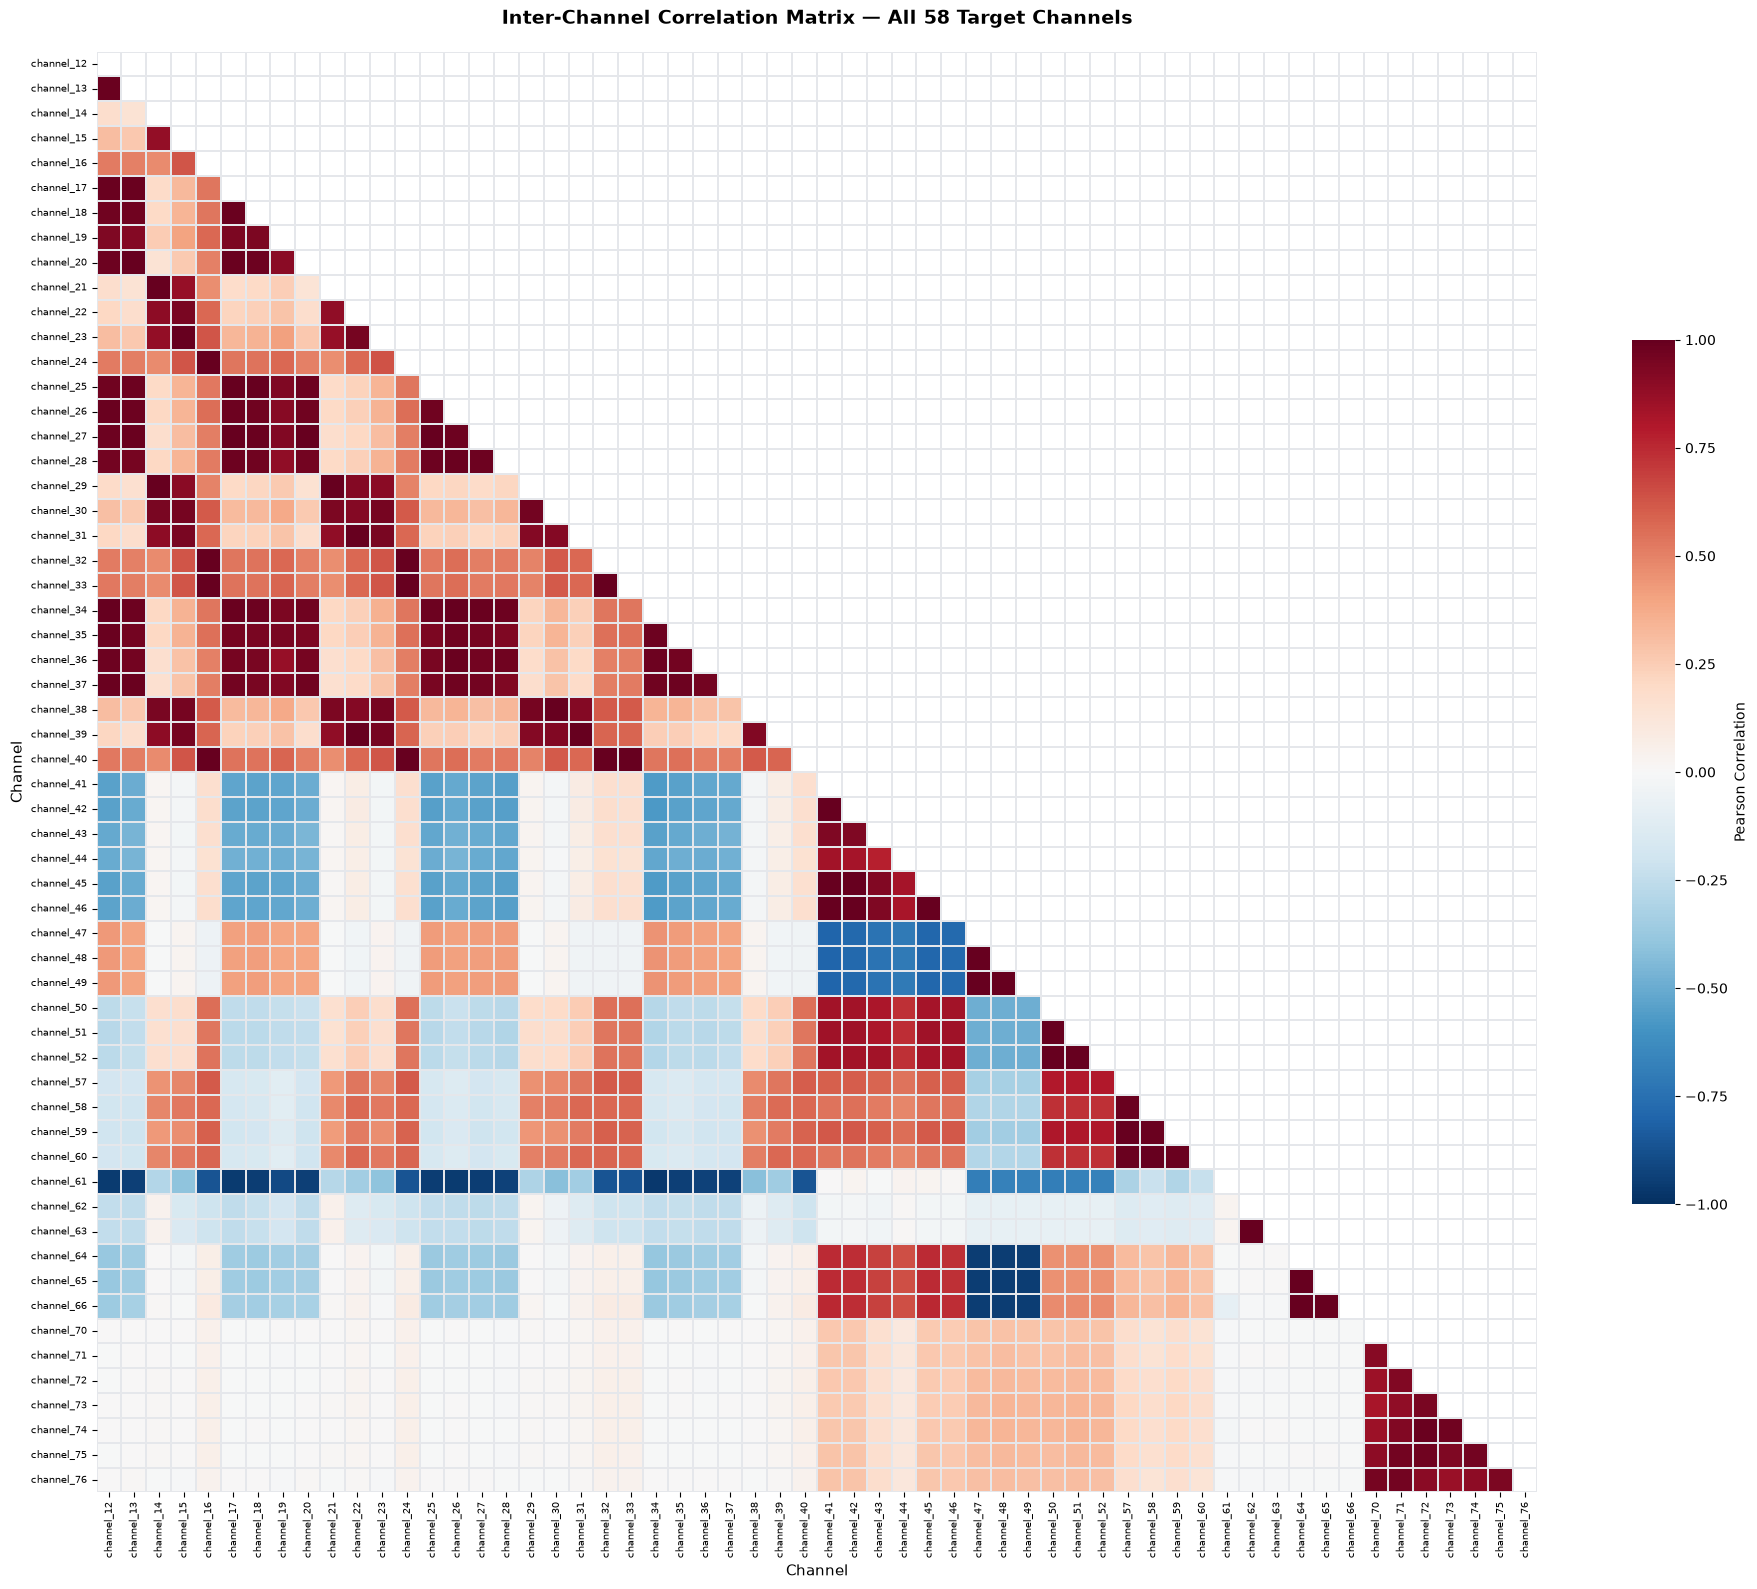

In [34]:
# Cell 15 — Plot the Correlation Matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute correlation on non-null rows
corr_matrix = df_combined.corr(method='pearson')

# Plot
fig, ax = plt.subplots(figsize=(20, 16))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # upper triangle mask

sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.3, linecolor='#E5E7EB', annot=False, square=True, ax=ax, cbar_kws={'shrink': 0.6, 'label': 'Pearson Correlation'})

ax.set_title('Inter-Channel Correlation Matrix — All 58 Target Channels', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Channel', fontsize=11)
ax.set_ylabel('Channel', fontsize=11)
ax.tick_params(axis='both', labelsize=7)

plt.tight_layout()
#plt.savefig('../Output/correlation_matrix.png', dpi=150, bbox_inches='tight') #Uncomment this line to save the figure as a PNG file
plt.show()

In [35]:
print("TOP 20 MOST STRONGLY CORRELATED CHANNEL PAIRS")
print("=" * 55)
# Get upper triangle only to avoid duplicates
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Channel_A', 'Channel_B', 'Correlation']
corr_pairs['Abs_Corr'] = corr_pairs['Correlation'].abs()
corr_pairs = corr_pairs.sort_values('Abs_Corr', ascending=False)

print("\nTop 10 Positively Correlated Pairs:")
print(corr_pairs[corr_pairs['Correlation'] > 0].head(10)
      [['Channel_A', 'Channel_B', 'Correlation']].to_string(index=False))

print("\nTop 10 Negatively Correlated Pairs:")
print(corr_pairs[corr_pairs['Correlation'] < 0].head(10)
      [['Channel_A', 'Channel_B', 'Correlation']].to_string(index=False))

print("\nChannels with weakest correlations (most independent):")
weakest = corr_pairs.groupby('Channel_A')['Abs_Corr'].mean().sort_values().head(10)
print(weakest.to_string())

TOP 20 MOST STRONGLY CORRELATED CHANNEL PAIRS

Top 10 Positively Correlated Pairs:
 Channel_A  Channel_B  Correlation
channel_64 channel_65     1.000000
channel_47 channel_48     1.000000
channel_47 channel_49     1.000000
channel_48 channel_49     1.000000
channel_62 channel_63     0.999981
channel_33 channel_40     0.999975
channel_24 channel_32     0.999933
channel_58 channel_60     0.999925
channel_16 channel_32     0.999920
channel_16 channel_24     0.999911

Top 10 Negatively Correlated Pairs:
 Channel_A  Channel_B  Correlation
channel_34 channel_61    -0.965420
channel_12 channel_61    -0.959116
channel_26 channel_61    -0.957255
channel_17 channel_61    -0.956166
channel_27 channel_61    -0.950432
channel_18 channel_61    -0.950125
channel_25 channel_61    -0.947459
channel_47 channel_64    -0.946721
channel_47 channel_65    -0.946721
channel_49 channel_64    -0.946718

Channels with weakest correlations (most independent):
Channel_A
channel_66    0.002849
channel_63    0.00594

In [36]:
# Sampling Irregularity Analysis
print("=" * 55)
print("SAMPLING IRREGULARITY ANALYSIS")
print("=" * 55)

sampling_stats = []

for ch_name, series in channel_dfs.items():
    # Compute time gaps between consecutive readings
    gaps = series.index.to_series().diff().dropna()
    gaps_seconds = gaps.dt.total_seconds()

    sampling_stats.append({
        'Channel'        : ch_name,
        'Total_Readings' : len(series),
        'Min_Gap_sec'    : gaps_seconds.min(),
        'Median_Gap_sec' : gaps_seconds.median(),
        'Mean_Gap_sec'   : gaps_seconds.mean(),
        'Max_Gap_sec'    : gaps_seconds.max(),
        'Std_Gap_sec'    : gaps_seconds.std(),
        'Gaps_over_1hr'  : (gaps_seconds > 3600).sum(),
        'Gaps_over_1day' : (gaps_seconds > 86400).sum(),
    })

df_sampling = pd.DataFrame(sampling_stats).sort_values('Median_Gap_sec')

print(f"\nMedian sampling interval distribution:")
print(df_sampling[['Channel','Total_Readings','Median_Gap_sec','Max_Gap_sec','Gaps_over_1hr','Gaps_over_1day']].to_string(index=False))

SAMPLING IRREGULARITY ANALYSIS

Median sampling interval distribution:
   Channel  Total_Readings  Median_Gap_sec  Max_Gap_sec  Gaps_over_1hr  Gaps_over_1day
channel_12        14258506           0.375    21330.000              5               0
channel_13        14258506           0.375    21330.000              5               0
channel_18        14258506           0.375    21330.000              5               0
channel_17        14258506           0.375    21330.000              5               0
channel_19        14258506           0.375    21330.000              5               0
channel_26        14258506           0.375    21330.000              5               0
channel_27        14258506           0.375    21330.000              5               0
channel_20        14258506           0.375    21330.000              5               0
channel_25        14258506           0.375    21330.000              5               0
channel_34        14258506           0.375    21330.000    

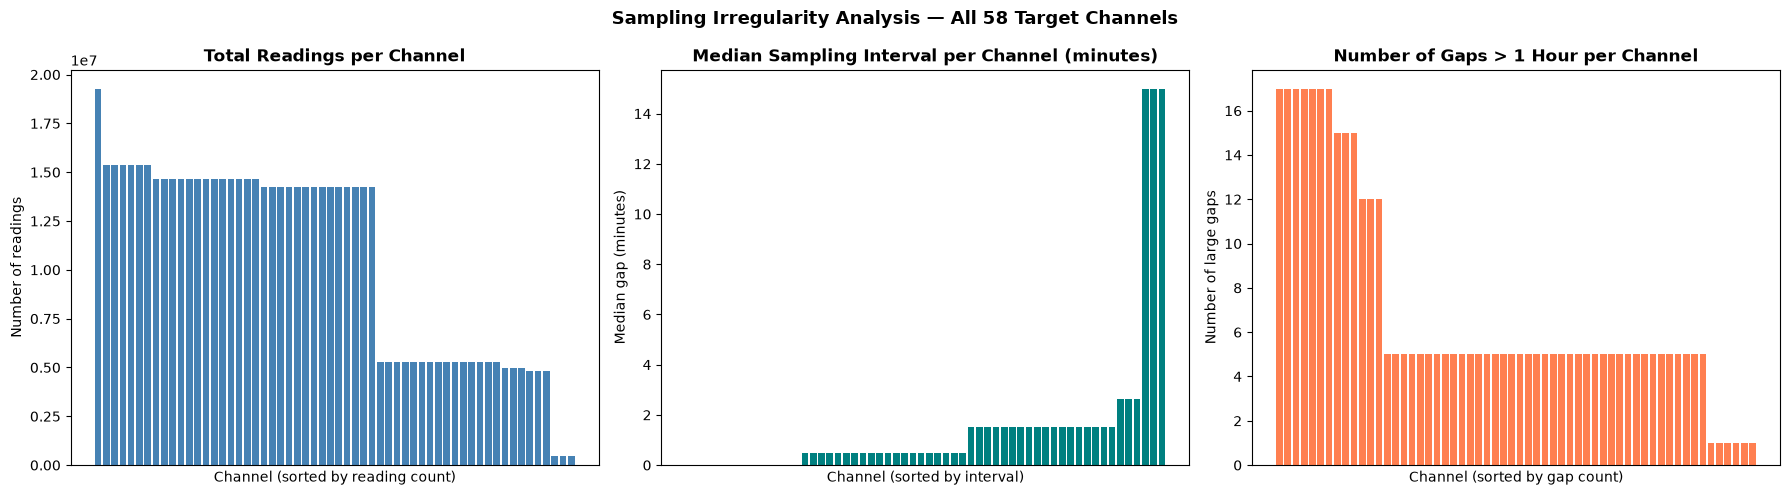

Saved to Output/sampling_irregularity.png

Channels with gaps > 1 day: 13
Channel with most large gaps: channel_73 (17 gaps > 1hr)

Fastest sampled channel: channel_12 (median gap = 0.4s)
Slowest sampled channel: channel_62 (median gap = 900.0s)


In [ ]:
# Visualize Sampling Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Total readings per channel
df_plot = df_sampling.sort_values('Total_Readings', ascending=False)
axes[0].bar(range(len(df_plot)), df_plot['Total_Readings'],color='steelblue', edgecolor='none')
axes[0].set_title('Total Readings per Channel', fontweight='bold')
axes[0].set_xlabel('Channel (sorted by reading count)')
axes[0].set_ylabel('Number of readings')
axes[0].set_xticks([])

# Plot 2 — Median sampling interval
df_plot2 = df_sampling.sort_values('Median_Gap_sec')
axes[1].bar(range(len(df_plot2)), df_plot2['Median_Gap_sec'] / 60,color='teal', edgecolor='none')
axes[1].set_title('Median Sampling Interval per Channel (minutes)',fontweight='bold')
axes[1].set_xlabel('Channel (sorted by interval)')
axes[1].set_ylabel('Median gap (minutes)')
axes[1].set_xticks([])

# Plot 3 — Number of gaps > 1 hour
df_plot3 = df_sampling.sort_values('Gaps_over_1hr', ascending=False)
axes[2].bar(range(len(df_plot3)), df_plot3['Gaps_over_1hr'],color='coral', edgecolor='none')
axes[2].set_title('Number of Gaps > 1 Hour per Channel',fontweight='bold')
axes[2].set_xlabel('Channel (sorted by gap count)')
axes[2].set_ylabel('Number of large gaps')
axes[2].set_xticks([])

plt.suptitle('Sampling Irregularity Analysis — All 58 Target Channels',fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../Output/sampling_irregularity.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved to Output/sampling_irregularity.png")

# Summary stats
print(f"\nChannels with gaps > 1 day: "
      f"{(df_sampling['Gaps_over_1day'] > 0).sum()}")
print(f"Channel with most large gaps: "
      f"{df_sampling.loc[df_sampling['Gaps_over_1hr'].idxmax(), 'Channel']} "
      f"({df_sampling['Gaps_over_1hr'].max()} gaps > 1hr)")
print(f"\nFastest sampled channel: "
      f"{df_sampling.iloc[0]['Channel']} "
      f"(median gap = {df_sampling.iloc[0]['Median_Gap_sec']:.1f}s)")
print(f"Slowest sampled channel: "
      f"{df_sampling.iloc[-1]['Channel']} "
      f"(median gap = {df_sampling.iloc[-1]['Median_Gap_sec']:.1f}s)")

In [ ]:
# Fixed version
import warnings
warnings.filterwarnings('ignore')

channels_to_analyze = {
    'channel_18': 'Sinusoidal wave (42 anomalies)',
    'channel_41': 'Flatline — Highly Anomalous (212 anomalies)',
    'channel_29': 'Irregular/Noisy (95 anomalies)',
    'channel_62': 'Sparse/Nearly Empty (5 anomalies)',
}

results = []

for ch_name, description in channels_to_analyze.items():
    print(f"Processing {ch_name}...")

    # Load channel
    ch_path = os.path.join(channels_folder, f"{ch_name}/{ch_name}")
    series = pd.read_pickle(ch_path)[ch_name]

    # Fix timezone — make index timezone-naive if it has timezone
    if series.index.tz is not None:
        series.index = series.index.tz_localize(None)

    # Get anomaly windows for this channel
    ch_anomalies = df_labels[df_labels['Channel'] == ch_name].copy()

    # Fix timezone on labels too
    ch_anomalies['StartTime'] = ch_anomalies['StartTime'].dt.tz_localize(None) \
        if ch_anomalies['StartTime'].dt.tz is not None \
        else ch_anomalies['StartTime']
    ch_anomalies['EndTime'] = ch_anomalies['EndTime'].dt.tz_localize(None) \
        if ch_anomalies['EndTime'].dt.tz is not None \
        else ch_anomalies['EndTime']

    # Build anomaly mask — True where timestamp falls inside any labeled window
    anomaly_mask = pd.Series(False, index=series.index)
    for _, row in ch_anomalies.iterrows():
        anomaly_mask[(series.index >= row['StartTime']) &
                     (series.index <= row['EndTime'])] = True

    normal_vals  = series[~anomaly_mask]
    anomaly_vals = series[anomaly_mask]

    print(f"  Normal readings:  {len(normal_vals):,}")
    print(f"  Anomaly readings: {len(anomaly_vals):,}")
    print(f"  Anomaly %:        {100*len(anomaly_vals)/len(series):.3f}%")

    if len(anomaly_vals) == 0:
        print(f"  → Only point anomalies (Duration=0), no readings captured")
        continue

    results.append({
        'Channel'      : ch_name,
        'Description'  : description,
        'Normal Mean'  : round(normal_vals.mean(), 4),
        'Anomaly Mean' : round(anomaly_vals.mean(), 4),
        'Mean Shift'   : round(abs(normal_vals.mean() - anomaly_vals.mean()), 4),
        'Normal Std'   : round(normal_vals.std(), 4),
        'Anomaly Std'  : round(anomaly_vals.std(), 4),
        'Std Change'   : round(anomaly_vals.std() - normal_vals.std(), 4),
    })

df_stats = pd.DataFrame(results)

Processing channel_18...
  Normal readings:  14,055,095
  Anomaly readings: 203,411
  Anomaly %:        1.427%
Processing channel_41...
  Normal readings:  15,193,404
  Anomaly readings: 187,765
  Anomaly %:        1.221%
Processing channel_29...
  Normal readings:  5,071,912
  Anomaly readings: 200,981
  Anomaly %:        3.812%
Processing channel_62...
  Normal readings:  486,865
  Anomaly readings: 583
  Anomaly %:        0.120%


In [39]:
df_stats

,Channel,Description,Normal Mean,Anomaly Mean,Mean Shift,Normal Std,Anomaly Std,Std Change
0,channel_18,Sinusoidal wave (42 anomalies),0.3072,0.3714,0.0642,0.0369,0.1636,0.1267
1,channel_41,Flatline — Highly Anomalous (212 anomalies),0.8098,0.7993,0.0105,0.0053,0.1329,0.1275
2,channel_29,Irregular/Noisy (95 anomalies),0.2839,0.3410,0.0571,0.0822,0.1969,0.1147
3,channel_62,Sparse/Nearly Empty (5 anomalies),0.4897,0.6015,0.1119,0.3235,0.0894,-0.2341


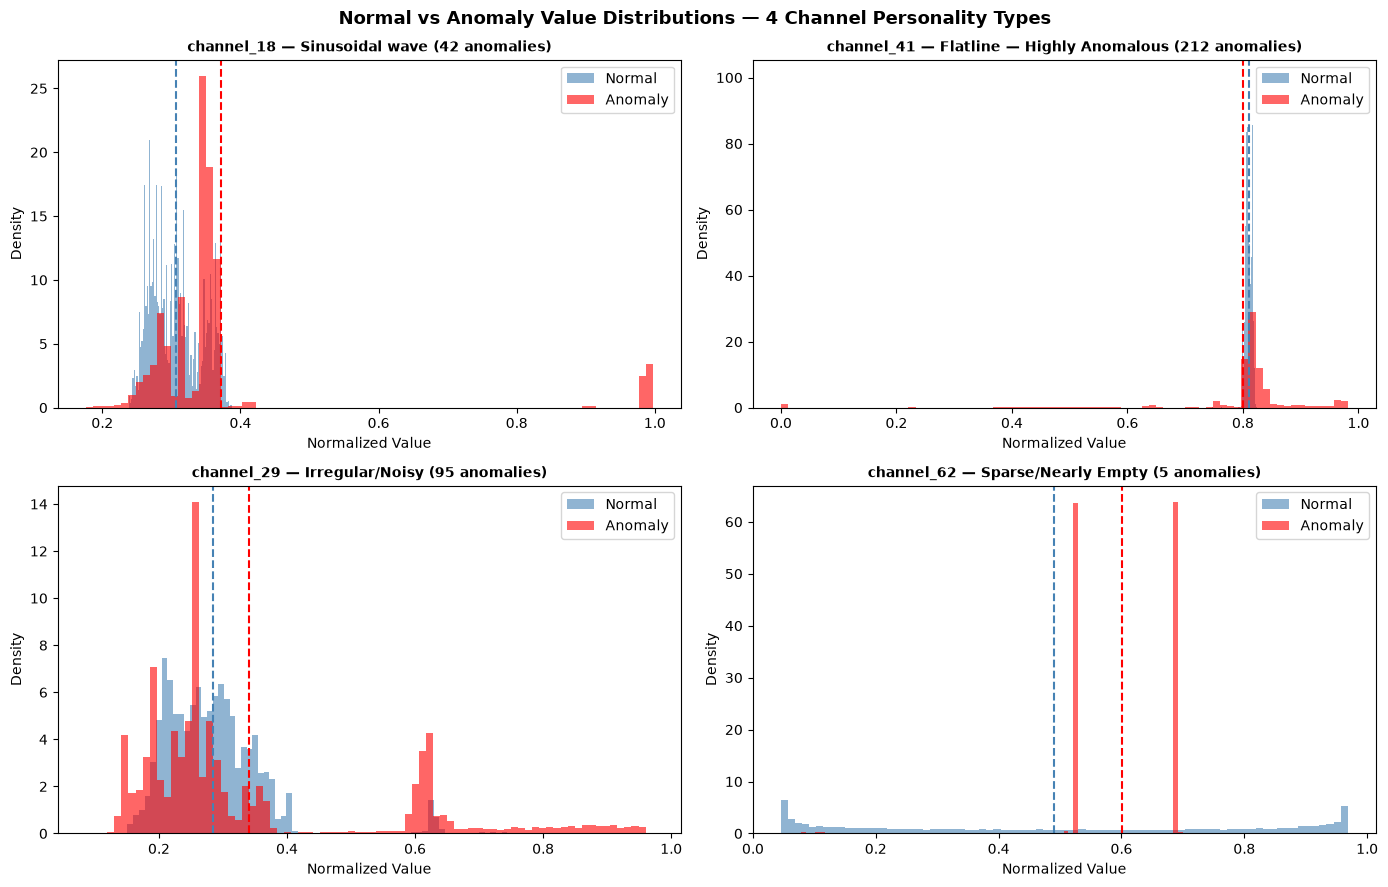

In [41]:
# Visualize Normal vs Anomaly distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (ch_name, description) in enumerate(channels_to_analyze.items()):
    ax = axes[i]

    ch_path = os.path.join(channels_folder, f"{ch_name}/{ch_name}")
    series = pd.read_pickle(ch_path)[ch_name]

    if series.index.tz is not None:
        series.index = series.index.tz_localize(None)

    ch_anomalies = df_labels[df_labels['Channel'] == ch_name].copy()
    ch_anomalies['StartTime'] = ch_anomalies['StartTime'].dt.tz_localize(None) \
        if ch_anomalies['StartTime'].dt.tz is not None \
        else ch_anomalies['StartTime']
    ch_anomalies['EndTime'] = ch_anomalies['EndTime'].dt.tz_localize(None) \
        if ch_anomalies['EndTime'].dt.tz is not None \
        else ch_anomalies['EndTime']

    anomaly_mask = pd.Series(False, index=series.index)
    for _, row in ch_anomalies.iterrows():
        anomaly_mask[(series.index >= row['StartTime']) &
                     (series.index <= row['EndTime'])] = True
    normal_vals  = series[~anomaly_mask]
    anomaly_vals = series[anomaly_mask]

    if len(anomaly_vals) == 0:
        ax.text(0.5, 0.5, 'No anomaly readings\n(point anomalies only)', ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.set_title(ch_name)
        continue
    ax.hist(normal_vals.sample(min(50000, len(normal_vals)), random_state=42),bins=80, alpha=0.6, color='steelblue', label='Normal', density=True)
    ax.hist(anomaly_vals.sample(min(10000, len(anomaly_vals)), random_state=42),bins=80, alpha=0.6, color='red', label='Anomaly', density=True)
    ax.set_title(f'{ch_name} — {description}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Normalized Value')
    ax.set_ylabel('Density')
    ax.legend()

    # Add vertical lines for means
    ax.axvline(normal_vals.mean(), color='steelblue',linestyle='--', linewidth=1.5, label=f'Normal mean')
    ax.axvline(anomaly_vals.mean(), color='red',linestyle='--', linewidth=1.5, label=f'Anomaly mean')

plt.suptitle('Normal vs Anomaly Value Distributions — 4 Channel Personality Types',fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('../Output/normal_vs_anomaly_distributions.png',dpi=150, bbox_inches='tight') #Uncomment this line to save the figure as a PNG file
plt.show()